In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import ast
import numpy as np
import os

In [2]:
MIN_5 = 320
MIN_10 = 620
MIN_15 = 1000
MIN_30 = 1820
MIN_60 = 3620
MIN_120 = 7220

def extract_location(file_path):
    file_name = os.path.basename(file_path)
    
    if "TENERIFE" in file_name and "FREEOLSEN" in file_name:
        return "Tenerife, Fred Olsen"
    elif "TENERIFE" in file_name and "ARMAS" in file_name:
        return "Tenerife, Armas"
    elif "espolon" in file_name and "petronor" in file_name:
        return "Espolón Petronor"
    else:
        return "Unknown Location"

def remove_label(classes_list, label):
    return [x for x in classes_list if x != label]

def first_element(classes_list):
    return [classes_list[0]] if classes_list else []

def interval_printing(average_interval):
    if average_interval > 0 and average_interval < MIN_5:
        print(f"The average interval between each audio file is 5 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_5 and average_interval < MIN_10:
        print(f"The average interval between each audio file is 10 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_10 and average_interval < MIN_15:
        print(f"The average interval between each audio file is 15 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_15 and average_interval < MIN_30:
        print(f"The average interval between each audio file is 30 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_30 and average_interval < MIN_60:
        print(f"The average interval between each audio file is 60 minutes ({round(average_interval)} seconds), which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_60 and average_interval < MIN_120:
        print(f"The average interval between each audio file is 120 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")

def insert_dates(df):
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["hour"] = df.index.hour
    df["minute"] = df.index.minute
    df["second"] = df.index.second
    df["weekday"] = df.index.day_name()

    weekday_translation = {
        "Monday": "Lunes",
        "Tuesday": "Martes",
        "Wednesday": "Miércoles",
        "Thursday": "Jueves",
        "Friday": "Viernes",
        "Saturday": "Sábado",
        "Sunday": "Domingo"
    }
    df["weekday"] = df["weekday"].replace(weekday_translation)
    df["weekday"] = df["weekday"].astype(str)
    df["day"] = df["day"].astype(str).str.zfill(2)
    df["fullday"] = df["day"] + "," + df["weekday"]

    return df

In [3]:
# tenerife_fred_olsen = "csv/avg_predictions_original_custom_10p_TENERIFE_FREEOLSEN.csv"
# tenerife_la_palma = "avg_predictions_original_custom_10p_LA_PALMA_ARMAS.csv"
espolon_petronor = "/home/aaccolombia/Documents/AAC/NoisePort/Noiseport/Audio_Processing/Test/yamnet_programs/results_20221026/10-probs/avg_predictions_original_custom_10espolon_petronor-20221006.csv"
torreta_petronor = "csv/avg_predictions_original_custom_10p_torreta_petronor-20221027.csv"

# df = pd.read_csv(tenerife_fred_olsen, sep=";")
# df = pd.read_csv("avg_predictions_original_custom_10p_LA_PALMA_ARMAS.csv")
# df = pd.read_csv(espolon_petronor)
df = pd.read_csv(torreta_petronor)

title = extract_location(espolon_petronor)

df

,files,datetime,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original
0,20221122_020040.WAV,2022-11-22 02:00:40,"['Nature', 'Motorised transport', 'Other', 'El...","[0.7328675080627626, 0.20443281633046298, 0.04...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.4518653, 0.3461102, 0.32665765, 0.30900782,...",1.709202
1,20221122_021545.WAV,2022-11-22 02:15:45,"['Nature', 'Motorised transport', 'Other', 'El...","[0.7182396091837704, 0.21351969110958557, 0.04...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.45076373, 0.34748504, 0.32408926, 0.2961105...",1.691241
2,20221122_023050.WAV,2022-11-22 02:30:50,"['Nature', 'Motorised transport', 'Other', 'El...","[0.706229397646303, 0.19690969491301744, 0.071...",1.0,"['Wind', 'Water', 'Wind noise (microphone)', '...","[0.37331346, 0.26903632, 0.25460875, 0.2317797...",1.316953
3,20221122_024555.WAV,2022-11-22 02:45:55,"['Nature', 'Motorised transport', 'Other', 'El...","[0.7058842294991364, 0.1880826098731498, 0.080...",1.0,"['Wind', 'Water', 'Wind noise (microphone)', '...","[0.38018826, 0.26752916, 0.24559729, 0.2407446...",1.330747
4,20221122_030100.WAV,2022-11-22 03:01:00,"['Nature', 'Motorised transport', 'Other', 'El...","[0.6793724459568746, 0.21245035044156668, 0.08...",1.0,"['Wind', 'Wind noise (microphone)', 'Water', '...","[0.37309822, 0.2350397, 0.20588902, 0.17602187...",1.128049
...,...,...,...,...,...,...,...,...
2419,20221122_004515.WAV,2022-11-22 00:45:15,"['Nature', 'Motorised transport', 'Other', 'El...","[0.6798726945058795, 0.25901714852006624, 0.04...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.4264397, 0.3423282, 0.29282346, 0.25479105,...",1.563088
2420,20221122_010020.WAV,2022-11-22 01:00:20,"['Nature', 'Motorised transport', 'Other', 'El...","[0.708378979153543, 0.2172988476175703, 0.0541...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.4557144, 0.3419927, 0.30009645, 0.2693006, ...",1.617367
2421,20221122_011525.WAV,2022-11-22 01:15:25,"['Nature', 'Motorised transport', 'Other', 'El...","[0.72175113877413, 0.21515471963493935, 0.0447...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.4751587, 0.37612486, 0.35296834, 0.3082858,...",1.811729
2422,20221122_013030.WAV,2022-11-22 01:30:30,"['Nature', 'Motorised transport', 'Other', 'El...","[0.7170434394907139, 0.20497496771343982, 0.05...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.43335503, 0.32296798, 0.29339993, 0.2806754...",1.575465


In [4]:
print("We are working with {} processing results".format(len(df)))
print(f"We are working within the time range from [ {df['datetime'].min()} ] to [ {df['datetime'].max()} ]")

df['datetime'] = pd.to_datetime(df['datetime'])
time_difference_seconds = df['datetime'].diff().dt.total_seconds()
average_interval = time_difference_seconds.mean()
interval_printing(average_interval)

We are working with 2424 processing results
We are working within the time range from [ 2022-10-27 08:17:45 ] to [ 2022-11-22 03:01:00 ]


In [5]:
# convert string to list
df['classes_custom'] = df['classes_custom'].apply(ast.literal_eval)

print(f"Type of the column: \t\t {type(df['classes_custom'])}")
print(f"Type of the first element: \t\t {type(df['classes_custom'][0])}")

# df['classes_custom'] = df['classes_custom'].apply(lambda x: remove_label(x, 'Nature'))
# df['classes_custom'] = df['classes_custom'].apply(lambda x: remove_label(x, 'Voice'))

df['classes_custom']

Type of the column: 		 <class 'pandas.core.series.Series'>
Type of the first element: 		 <class 'list'>


0       [Nature, Motorised transport, Other, Electro-m...
1       [Nature, Motorised transport, Other, Electro-m...
2       [Nature, Motorised transport, Other, Electro-m...
3       [Nature, Motorised transport, Other, Electro-m...
4       [Nature, Motorised transport, Other, Electro-m...
                              ...                        
2419    [Nature, Motorised transport, Other, Electro-m...
2420    [Nature, Motorised transport, Other, Electro-m...
2421    [Nature, Motorised transport, Other, Electro-m...
2422    [Nature, Motorised transport, Other, Electro-m...
2423    [Nature, Motorised transport, Other, Electro-m...
Name: classes_custom, Length: 2424, dtype: object

In [6]:
# print("Nature" in df['classes_custom'])
# print("Voice" in df['classes_custom'])

In [7]:
df['classes_custom'] = df['classes_custom'].apply(first_element)
df['classes_custom']

0       [Nature]
1       [Nature]
2       [Nature]
3       [Nature]
4       [Nature]
          ...   
2419    [Nature]
2420    [Nature]
2421    [Nature]
2422    [Nature]
2423    [Nature]
Name: classes_custom, Length: 2424, dtype: object

In [8]:
print(f"These are the class count:\n\n{df['classes_custom'].value_counts()}")

print(f"\nThese are the class summed: \t\t {df['classes_custom'].value_counts().sum()}")
print(f"This is the lenght of the dataframe \t {len(df)}")

These are the class count:

classes_custom
[Nature]                 1457
[Motorised transport]     908
[Electro-mechanical]       49
[Other]                    10
Name: count, dtype: int64

These are the class summed: 		 2424
This is the lenght of the dataframe 	 2424


In [9]:
df['single_class'] = df['classes_custom'].apply(lambda x: x[0] if x else None)
df.set_index("datetime", inplace=True)
df = insert_dates(df)

In [10]:
df

,files,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original,single_class,year,month,day,hour,minute,second,weekday,fullday
datetime,,,,,,,,,,,,,,,,
2022-11-22 02:00:40,20221122_020040.WAV,[Nature],"[0.7328675080627626, 0.20443281633046298, 0.04...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.4518653, 0.3461102, 0.32665765, 0.30900782,...",1.709202,Nature,2022,11,22,2,0,40,Martes,"22,Martes"
2022-11-22 02:15:45,20221122_021545.WAV,[Nature],"[0.7182396091837704, 0.21351969110958557, 0.04...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.45076373, 0.34748504, 0.32408926, 0.2961105...",1.691241,Nature,2022,11,22,2,15,45,Martes,"22,Martes"
2022-11-22 02:30:50,20221122_023050.WAV,[Nature],"[0.706229397646303, 0.19690969491301744, 0.071...",1.0,"['Wind', 'Water', 'Wind noise (microphone)', '...","[0.37331346, 0.26903632, 0.25460875, 0.2317797...",1.316953,Nature,2022,11,22,2,30,50,Martes,"22,Martes"
2022-11-22 02:45:55,20221122_024555.WAV,[Nature],"[0.7058842294991364, 0.1880826098731498, 0.080...",1.0,"['Wind', 'Water', 'Wind noise (microphone)', '...","[0.38018826, 0.26752916, 0.24559729, 0.2407446...",1.330747,Nature,2022,11,22,2,45,55,Martes,"22,Martes"
2022-11-22 03:01:00,20221122_030100.WAV,[Nature],"[0.6793724459568746, 0.21245035044156668, 0.08...",1.0,"['Wind', 'Wind noise (microphone)', 'Water', '...","[0.37309822, 0.2350397, 0.20588902, 0.17602187...",1.128049,Nature,2022,11,22,3,1,0,Martes,"22,Martes"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-22 00:45:15,20221122_004515.WAV,[Nature],"[0.6798726945058795, 0.25901714852006624, 0.04...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.4264397, 0.3423282, 0.29282346, 0.25479105,...",1.563088,Nature,2022,11,22,0,45,15,Martes,"22,Martes"
2022-11-22 01:00:20,20221122_010020.WAV,[Nature],"[0.708378979153543, 0.2172988476175703, 0.0541...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.4557144, 0.3419927, 0.30009645, 0.2693006, ...",1.617367,Nature,2022,11,22,1,0,20,Martes,"22,Martes"
2022-11-22 01:15:25,20221122_011525.WAV,[Nature],"[0.72175113877413, 0.21515471963493935, 0.0447...",1.0,"['Wind', 'Wind noise (microphone)', 'Ocean', '...","[0.4751587, 0.37612486, 0.35296834, 0.3082858,...",1.811729,Nature,2022,11,22,1,15,25,Martes,"22,Martes"


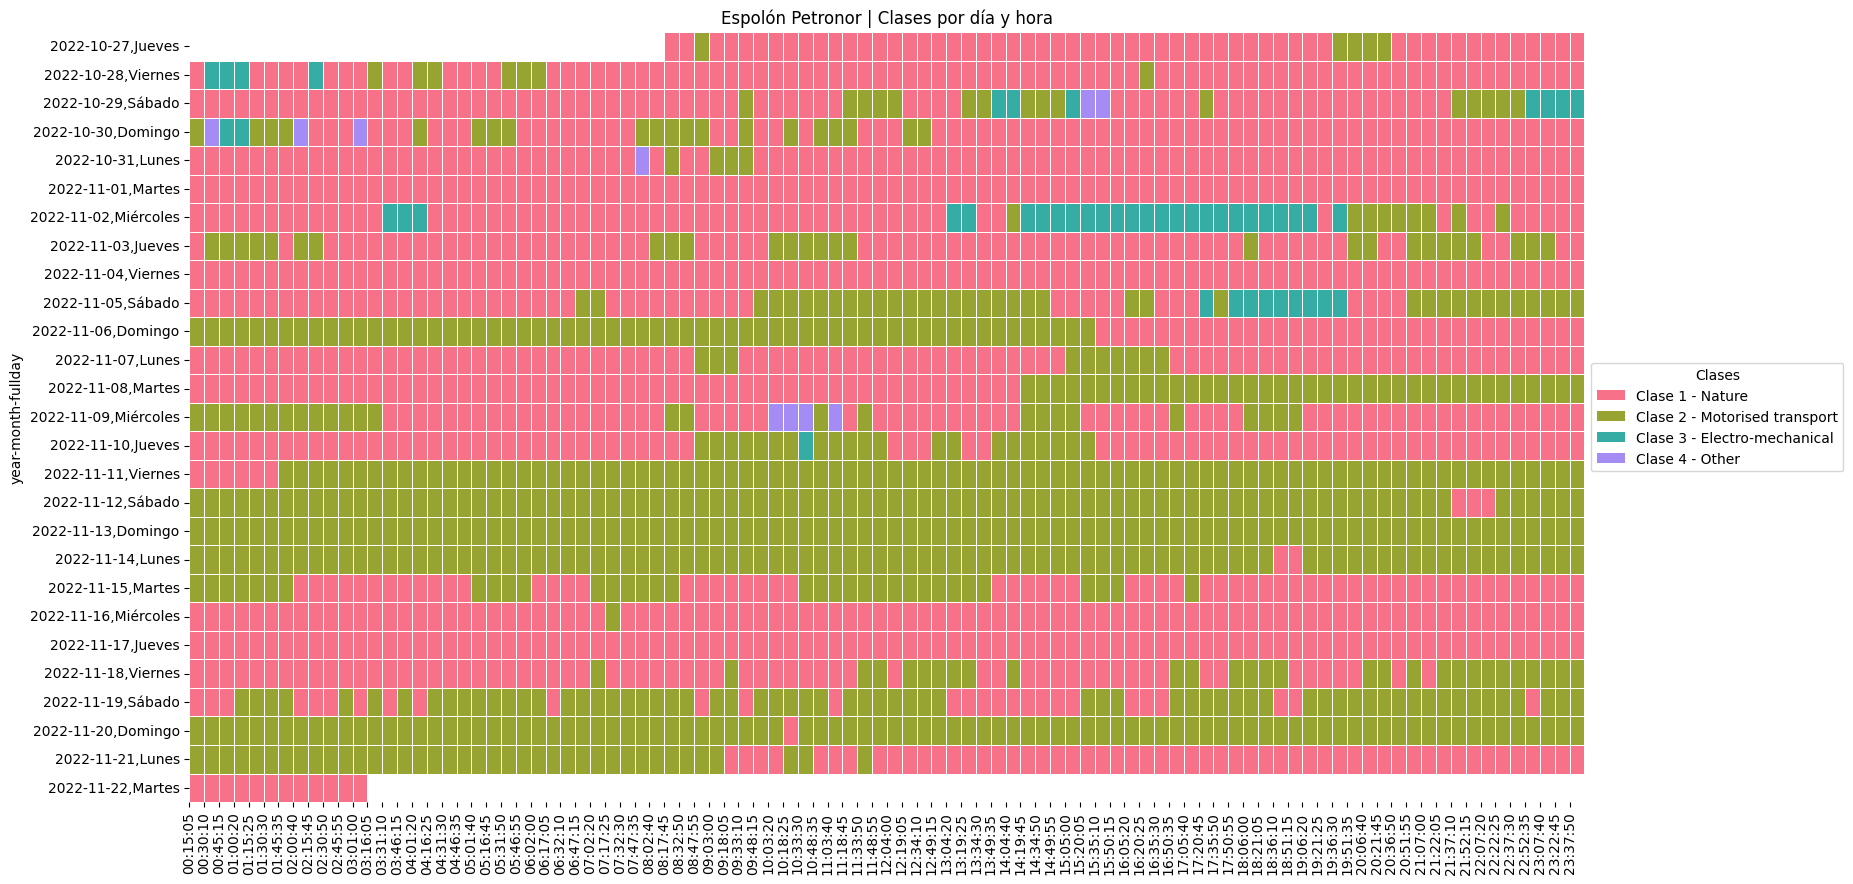

In [11]:
df = df.sort_values(by=["year", "month", "fullday"])

class_to_num = {class_name: index+1 for index, class_name in enumerate(df['single_class'].unique())}
df['class_num'] = df['single_class'].map(class_to_num)

clase_nombres = {v: k for k, v in class_to_num.items()}

legend_colors = sns.color_palette("husl", n_colors=len(clase_nombres))
cmap = sns.color_palette(legend_colors, n_colors=len(clase_nombres))
legend_elements = [Patch(facecolor=color, label=f"Clase {cls_num} - {clase_nombres.get(cls_num, '')}") for cls_num, color in zip(clase_nombres.keys(), cmap)]

plt.figure(figsize=(18, 10))

day_class = pd.pivot_table(data=df, columns=df.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

plt.show()

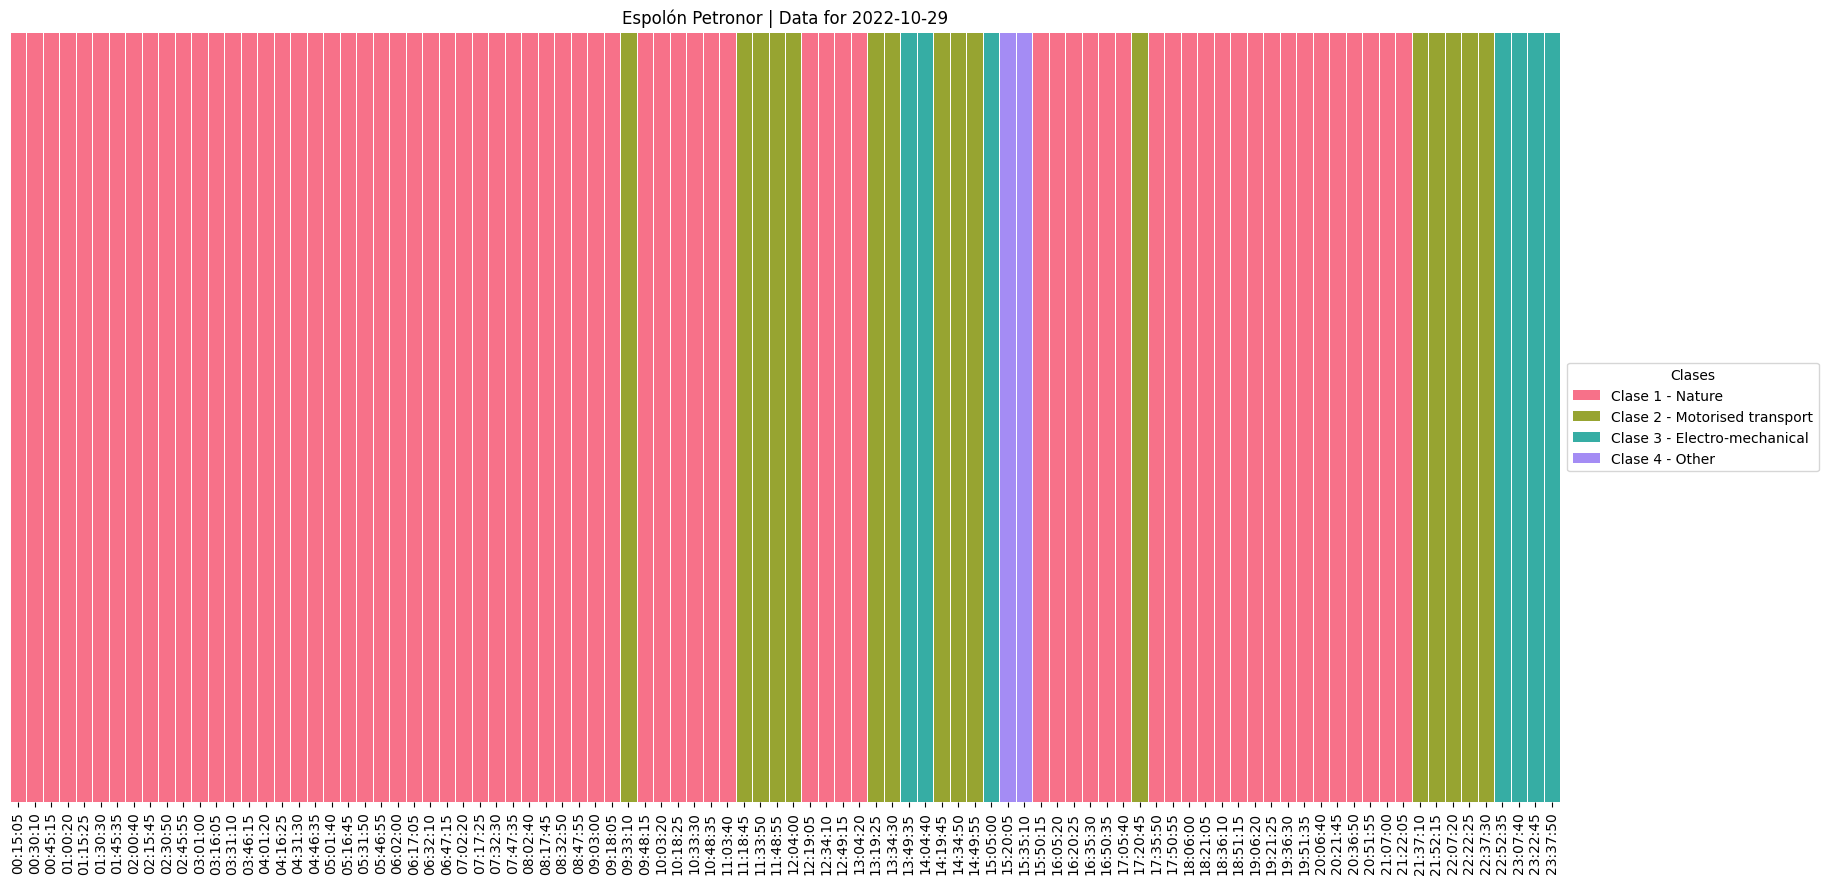

In [12]:
day = "29"

# Filter for the specific day across all years and months
df_xth = df[df["fullday"].str.startswith(day)]

if df_xth.empty:
    print(f"No data for the {day}th day across all years and months. Skipping...")
else:
    plt.figure(figsize=(20, 10))
    
    # Pivot with year and month as multi-index
    day_class = pd.pivot_table(data=df_xth, columns=df_xth.index.time, index=["year", "month"], values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
    
    if day_class.isna().all().all() or day_class.empty:
        print(f"No valid data for the {day}th day. Skipping...")
    else:
        unique_classes = day_class.dropna().values.flatten()
        unique_classes = set(unique_classes)
        
        current_legend_elements = [Patch(facecolor=cmap[int(cls_num)-1], label=f"Clase {cls_num} - {clase_nombres[cls_num]}") for cls_num in unique_classes]
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(clase_nombres))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        
        # Remove the y-tick labels (to hide year and month labels on y-axis)
        ax.yaxis.set_visible(False)
        
        # Update title to include year, month, and day
        years = "-".join(map(str, df_xth["year"].unique()))
        months = "-".join(map(str, sorted(df_xth["month"].unique())))
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {years}-{months}-{day}")

        plt.show()

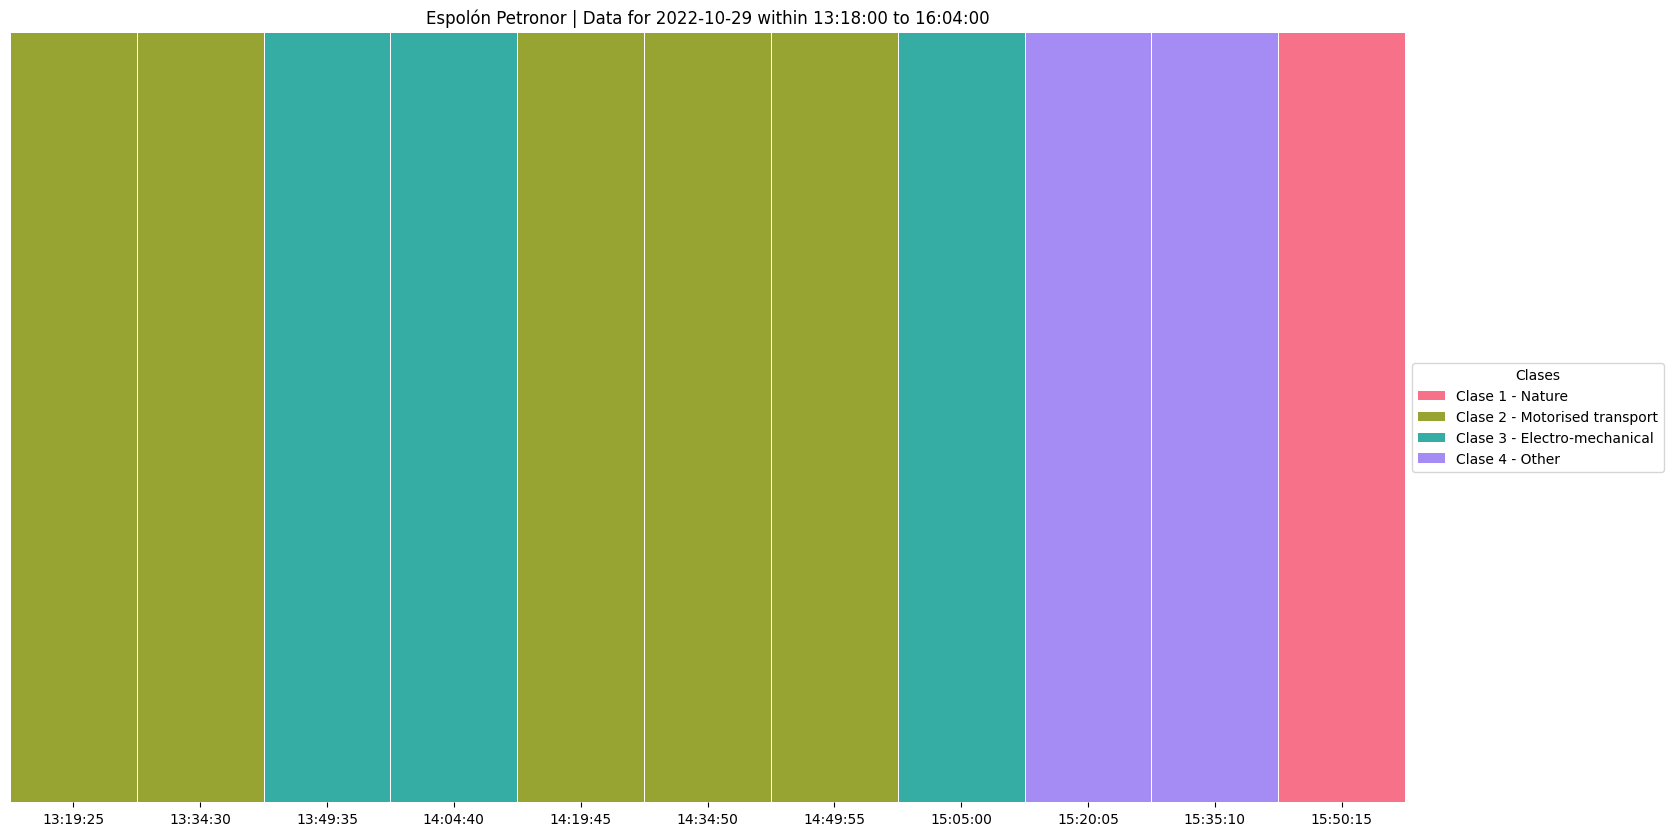

No data for the 29th day in Year: 2022, Month: 11 within the specified time range. Skipping...


In [15]:
day = "29"

for year in sorted(df["year"].unique()):
    df_year = df[df["year"] == year]
    for month in sorted(df_year["month"].unique()):
        df_temp = df_year[df_year["month"] == month]
        
        df_xth = df_temp[df_temp["fullday"].str.startswith(day)]
        
        start_time = pd.to_datetime("13:18:00").time()
        end_time = pd.to_datetime("16:04:00").time()
        time_mask = (df_xth.index.time >= start_time) & (df_xth.index.time <= end_time)
        df_xth_filtered = df_xth[time_mask]
        
        if df_xth_filtered.empty:
            print(f"No data for the {day}th day in Year: {year}, Month: {month} within the specified time range. Skipping...")
            continue
        
        plt.figure(figsize=(18, 10))
        
        day_class = pd.pivot_table(data=df_xth_filtered, columns=df_xth_filtered.index.time, index="fullday", values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
        
        if day_class.isna().all().all() or day_class.empty:
            print(f"No valid data for Year: {year}, Month: {month}, Day: {day} within the specified time range. Skipping...")
            continue
        
        unique_classes = day_class.dropna().values.flatten()
        unique_classes = set(unique_classes)
        
        current_legend_elements = [Patch(facecolor=cmap[int(cls_num)-1], label=f"Clase {cls_num} - {clase_nombres[cls_num]}") for cls_num in unique_classes]
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(clase_nombres))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
        # Completely hide the y-axis
        ax.yaxis.set_visible(False)
        
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {year}-{month}-{day} within {start_time} to {end_time}")

        plt.show()
